---
### Group Alpha
- Amira Aqila Afdhal
- Christian
- Ditya Ayu Anjani
---

# Project Overview: Telco Customer Churn

**Stakeholders**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

**Problem Statement**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

**Goal**
>Lorem ipsum dolor sit amet, consectetur adipiscing elit. In iaculis tortor nec egestas tempor. Nam pretium dictum hendrerit. Aliquam at molestie lorem, at commodo nisl. Sed faucibus ex magna, quis ullamcorper nisi posuere quis. Integer condimentum nibh ac elementum dapibus. Duis vitae venenatis ante. Pellentesque at justo fermentum, varius enim eget, porttitor eros. Vivamus luctus leo vel augue euismod sollicitudin. Quisque congue purus in ligula laoreet, a efficitur sem pellentesque. Suspendisse vel maximus urna.

# Import Libraries

In [4]:
# Save Model
import pickle
import os

# Data & Array
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & Feature Engineering
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Model Selection & Training
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy.stats import randint

# Optional: to suppress warnings
import warnings

warnings.filterwarnings("ignore")

# Optional: Pandas display option
pd.set_option("display.max_columns", 200)
pd.set_option("display.max_colwidth", None)

# Data
1. Read Dataset
1. Data Profiling
1. Data Cleansing
1. Data Transformation

## 1. Read Dataset

---
**Feature Descriptions**
1. `customerID`
1. `gender` Whether the customer is a male or a female
1. `SeniorCitizen` Whether the customer is a senior citizen or not (1, 0)
1. `Partner` Whether the customer has a partner or not (Yes, No)
1. `Dependents` Whether the customer has dependents or not (Yes, No)
1. `tenure` Number of months the customer has stayed with the company
1. `PhoneService` Whether the customer has a phone service or not (Yes, No)
1. `MultipleLines` Whether the customer has multiple lines or not (Yes, No, No phone service)
1. `InternetService` Customer’s internet service provider (DSL, Fiber optic, No)
1. `OnlineSecurity` Whether the customer has online security or not (Yes, No, No internet service)
1. `OnlineBackup` Whether the customer has online backup or not (Yes, No, No internet service)
1. `DeviceProtection` Whether the customer has device protection or not (Yes, No, No internet service)
1. `TechSupport` Whether the customer has tech support or not (Yes, No, No internet service)
1. `StreamingTV` Whether the customer has streaming TV or not (Yes, No, No internet service)
1. `StreamingMovies` Whether the customer has streaming movies or not (Yes, No, No internet service)
1. `Contract` The contract term of the customer (Month-to-month, One year, Two year)
1. `PaperlessBilling` Whether the customer has paperless billing or not (Yes, No)
1. `PaymentMethod` The customer’s payment method (Electronic check, Mailed check, Bank transfer (automatic), Credit card (automatic))
1. `MonthlyCharges` The amount charged to the customer monthly
1. `TotalCharges` The total amount charged to the customer
1. `Churn` Whether the customer churned or not (Yes or No)
---

In [8]:
# Telco Customer Churn Dataset
df = pd.read_csv("input/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
4854,1337-BOZWO,Male,0,Yes,Yes,18,No,No phone service,DSL,No,Yes,Yes,No,Yes,No,One year,No,Credit card (automatic),46.40,812.4,No
6011,5917-HBSDW,Female,0,Yes,Yes,37,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Electronic check,19.35,683.75,No
3329,5366-OBVMR,Female,0,Yes,No,18,Yes,No,DSL,No,No,No,Yes,No,No,Month-to-month,Yes,Mailed check,50.30,908.75,No
980,3318-ISQFQ,Female,0,No,No,20,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Bank transfer (automatic),19.50,413,No
4463,4603-JANFB,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.85,69.85,Yes


## 2. Data profiling

In [10]:
# Column data type
dtype = pd.DataFrame(df.dtypes).rename(columns={0: "Data Type"})

# Column value
value = pd.DataFrame(df.head(1)).T.rename(columns={0: "Value"})

dtype.join(value)

,Data Type,Value
customerID,object,7590-VHVEG
gender,object,Female
SeniorCitizen,int64,0
Partner,object,Yes
Dependents,object,No
tenure,int64,1
PhoneService,object,No
MultipleLines,object,No phone service
InternetService,object,DSL
OnlineSecurity,object,No


In [11]:
# Check invalid value
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [12]:
# Check unique value
pd.DataFrame(df.nunique()).rename(columns={0: "Unique Value"})

,Unique Value
customerID,7043
gender,2
SeniorCitizen,2
Partner,2
Dependents,2
tenure,73
PhoneService,2
MultipleLines,3
InternetService,3
OnlineSecurity,3


In [13]:
# Drop the columns you don't want to analyze
check_unique = df.drop(
    columns=["customerID", "MonthlyCharges", "TotalCharges", "tenure"]
)

# Unique values for each remaining column
unique_values = pd.DataFrame({
    'Column': check_unique.columns,
    'Unique Values': [', '.join(map(str, check_unique[col].dropna().unique())) 
                     for col in check_unique.columns]
})

# Display the result
unique_values

,Column,Unique Values
0,gender,"Female, Male"
1,SeniorCitizen,"0, 1"
2,Partner,"Yes, No"
3,Dependents,"No, Yes"
4,PhoneService,"No, Yes"
5,MultipleLines,"No phone service, No, Yes"
6,InternetService,"DSL, Fiber optic, No"
7,OnlineSecurity,"No, Yes, No internet service"
8,OnlineBackup,"Yes, No, No internet service"
9,DeviceProtection,"No, Yes, No internet service"


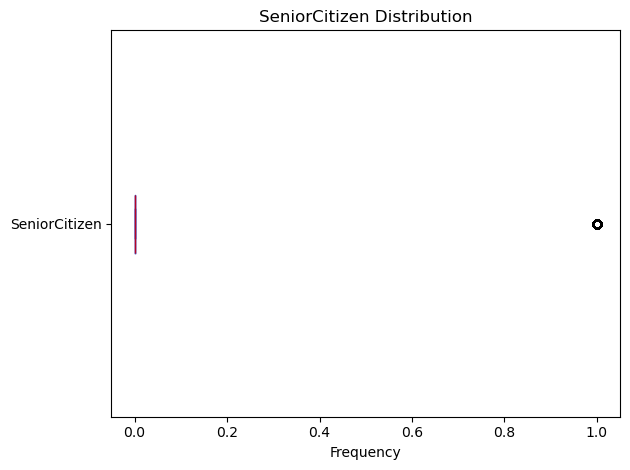

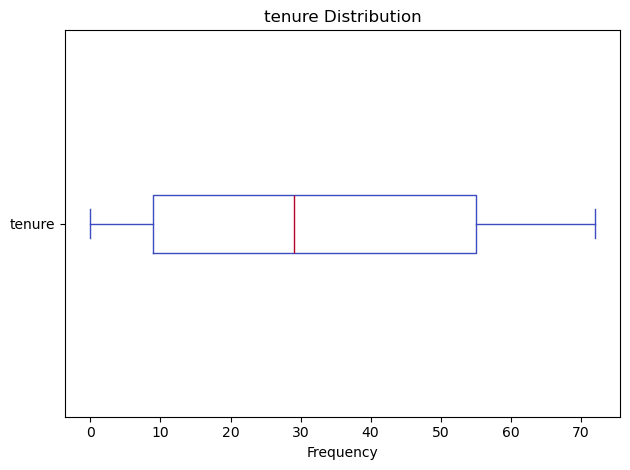

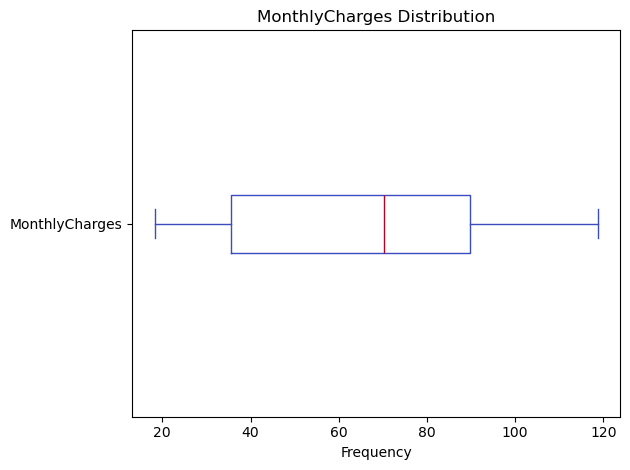

In [14]:
# Check outlier
cols = ["SeniorCitizen", "tenure", "MonthlyCharges"]

for col in cols:
    df[col].plot(kind="box", cmap="coolwarm", vert=False)

    plt.title(f"{col} Distribution")
    plt.xlabel("Frequency")

    plt.tight_layout()
    plt.show()
    print()

In [15]:
# Check correlation
check_corr = df[["SeniorCitizen", "tenure", "MonthlyCharges"]]

check_corr.corr()

,SeniorCitizen,tenure,MonthlyCharges
SeniorCitizen,1.000000,0.016567,0.220173
tenure,0.016567,1.000000,0.247900
MonthlyCharges,0.220173,0.247900,1.000000


**Result:**
1. 

## 3. Data Cleansing
1. Handle Missing Values
2. Remove Duplicates
3. Remove Invalid Values
4. Remove Outliers

### Handle Missing Values

In [19]:
# Check how many row effected by missing values
check_missing = pd.DataFrame(
    round(df.isna().sum() / len(df) * 100, 2).astype(str) + "%"
).rename(columns={0: "Missing Value"})

check_missing[check_missing["Missing Value"] != "0.0%"]

,Missing Value


<div class="alert alert-success">There are no missing values</div>

### Remove Duplicates

In [22]:
# Check how many row have duplicate
pd.DataFrame(df.duplicated().value_counts())

,count
False,7043


<div class="alert alert-success">There are no duplicates</div>

### Remove Invalid Values

<div class="alert alert-success">There are no invalid values</div>

### Remove Outliers
1. `fare_amount`>200
1. `trip_distance`>200
1. `tip_amount`>50

<div class="alert alert-success">There are no outliers</div>

## 4. Data Transformation
- Covert Data Types
- Create Columns
- Value Mapping

### Convert Data Types

### Value Mapping

### Create Columns